In [10]:

pip install category_encoders

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')


In [12]:
df=pd.read_csv('/content/2016_Building_Energy_Benchmarking.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [14]:
print(f"Shape initiale : {df.shape}")

columns_à_supprimer = [
    'PropertyName', 'Address', 'TaxParcelIdentificationNumber',
    'ZipCode', 'DataYear', 'City', 'CouncilDistrictCode', 'State',
    'Comments', 'Electricity(kWh)', 'NaturalGas(therms)',
    'ComplianceStatus', 'OSEBuildingID', 'SourceEUI(kBtu/sf)',
    'DefaultData', 'YearsENERGYSTARCertified', 'Outlier',
    'SiteEUI(kBtu/sf)', 'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
    'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
    'SiteEnergyUseWN(kBtu)', 'SourceEUIWN(kBtu/sf)',
    'GHGEmissionsIntensity', 'SiteEUIWN(kBtu/sf)',
    'SteamUse(kBtu)', 'NaturalGas(kBtu)', 'Electricity(kBtu)',
    'ListOfAllPropertyUseTypes', 'PropertyGFABuilding(s)',

]
df = df.drop(columns=columns_à_supprimer, errors='ignore')

Shape initiale : (3376, 46)


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BuildingType            3376 non-null   object 
 1   PrimaryPropertyType     3376 non-null   object 
 2   Neighborhood            3376 non-null   object 
 3   Latitude                3376 non-null   float64
 4   Longitude               3376 non-null   float64
 5   YearBuilt               3376 non-null   int64  
 6   NumberofBuildings       3368 non-null   float64
 7   NumberofFloors          3376 non-null   int64  
 8   PropertyGFATotal        3376 non-null   int64  
 9   PropertyGFAParking      3376 non-null   int64  
 10  LargestPropertyUseType  3356 non-null   object 
 11  ENERGYSTARScore         2533 non-null   float64
 12  SiteEnergyUse(kBtu)     3371 non-null   float64
 13  TotalGHGEmissions       3367 non-null   float64
dtypes: float64(6), int64(4), object(4)
memor

In [16]:
df.describe()

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
count,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,2533.000000,3.371000e+03,3367.000000
mean,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,67.918674,5.403667e+06,119.723971
std,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,26.873271,2.161063e+07,538.832227
min,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,1.000000,0.000000e+00,-0.800000
25%,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,53.000000,9.251286e+05,9.495000
50%,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,75.000000,1.803753e+06,33.920000
75%,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,90.000000,4.222455e+06,93.940000
max,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,100.000000,8.739237e+08,16870.980000


In [17]:
###incoherence

df[df['NumberofFloors']>76].shape[0]
df = df[df['PropertyGFATotal'] > 0]
df.loc[df['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1
df.loc[df['TotalGHGEmissions'] < 0, 'TotalGHGEmissions'] = 0

In [18]:
df.describe(include='object')

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType
count,3376,3376,3376,3356
unique,8,24,19,56
top,NonResidential,Low-Rise Multifamily,DOWNTOWN,Multifamily Housing
freq,1460,987,573,1667


In [19]:
df.isnull().sum()

,0
BuildingType,0
PrimaryPropertyType,0
Neighborhood,0
Latitude,0
Longitude,0
YearBuilt,0
NumberofBuildings,8
NumberofFloors,0
PropertyGFATotal,0
PropertyGFAParking,0


In [20]:

df['PrimaryPropertyType'].unique()


array(['Hotel', 'Other', 'Mid-Rise Multifamily', 'Mixed Use Property',
       'K-12 School', 'University', 'Small- and Mid-Sized Office',
       'Self-Storage Facility', 'Warehouse', 'Large Office',
       'Senior Care Community', 'Medical Office', 'Retail Store',
       'Hospital', 'Residence Hall', 'Distribution Center',
       'Worship Facility', 'Low-Rise Multifamily',
       'Supermarket / Grocery Store', 'Laboratory',
       'Refrigerated Warehouse', 'Restaurant', 'High-Rise Multifamily',
       'Office'], dtype=object)

In [21]:
print("Avant :", df.shape[0])

Avant : 3376


In [22]:

non_residential_types = [
    'NonResidential',
    'Nonresidential COS',
    'Nonresidential WA',
    'SPS-District K-12',
    'Campus'
]

df = df[df['BuildingType'].isin(non_residential_types)].copy()

print("Après :", df.shape[0])

Après : 1668


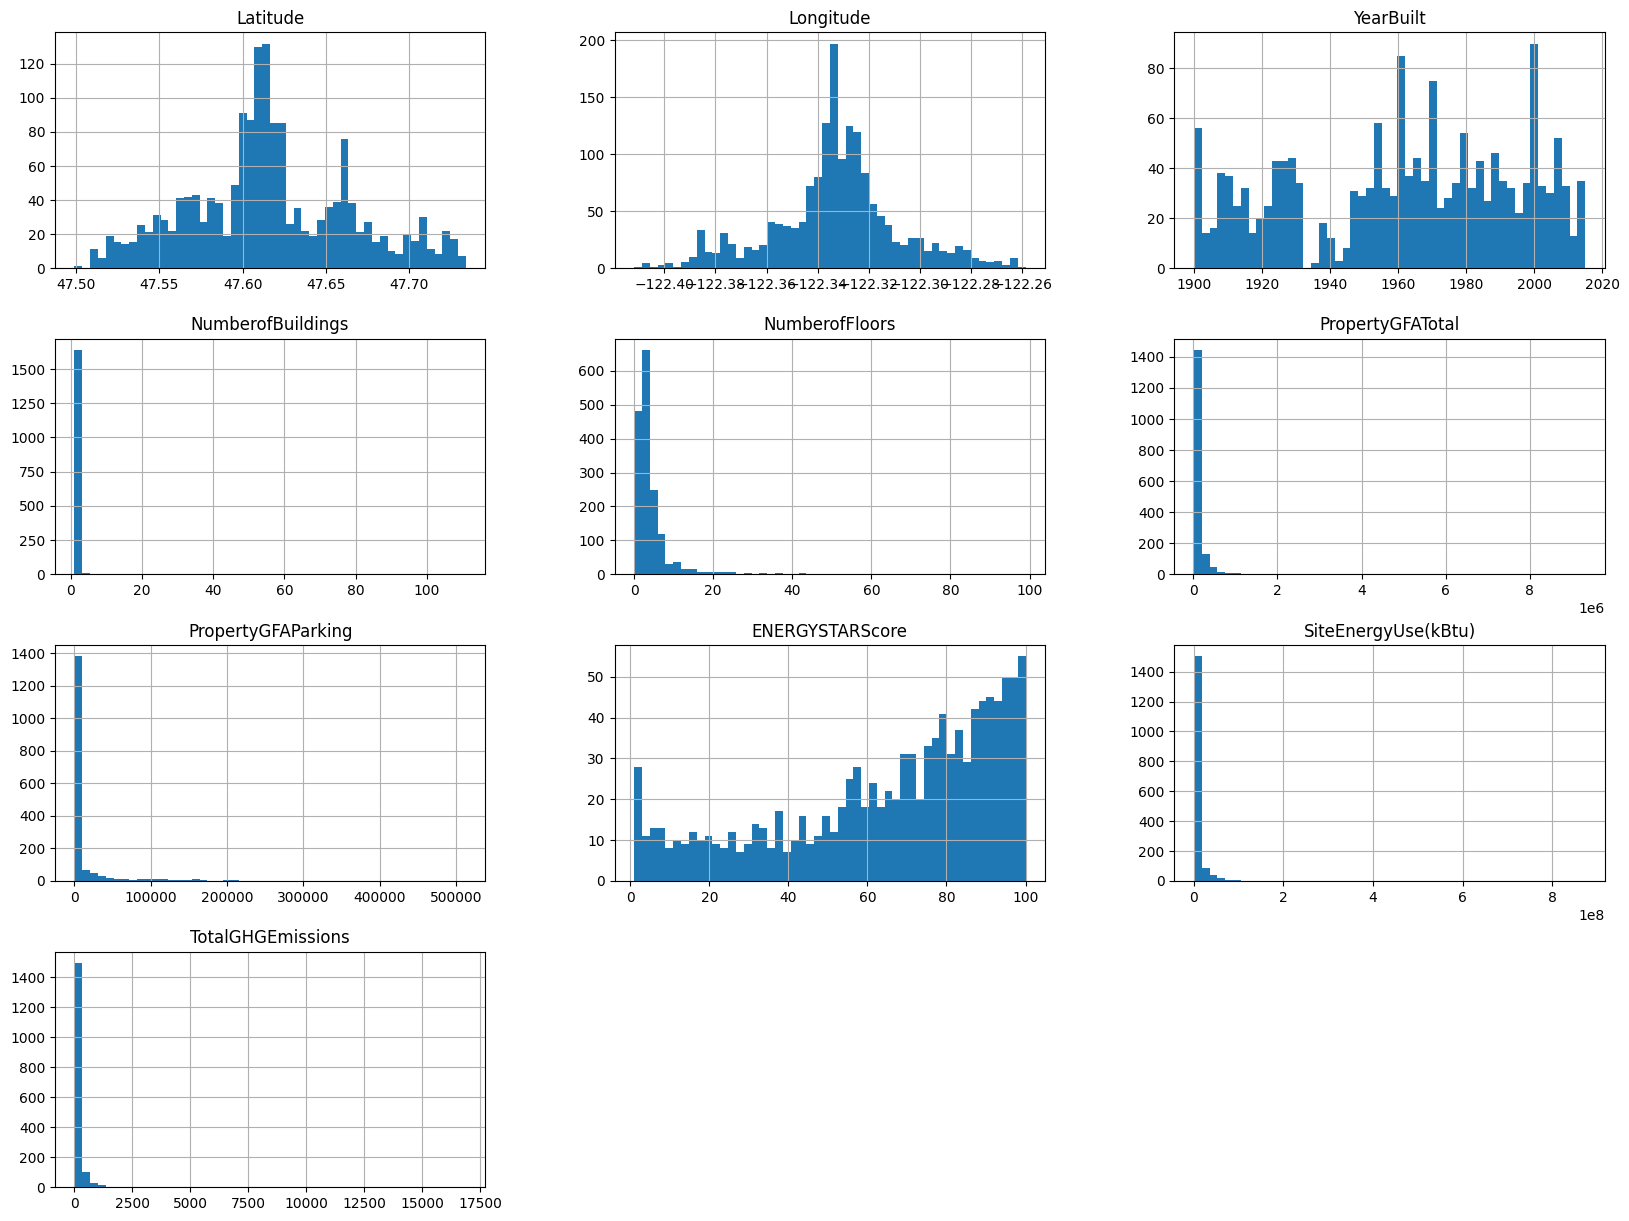

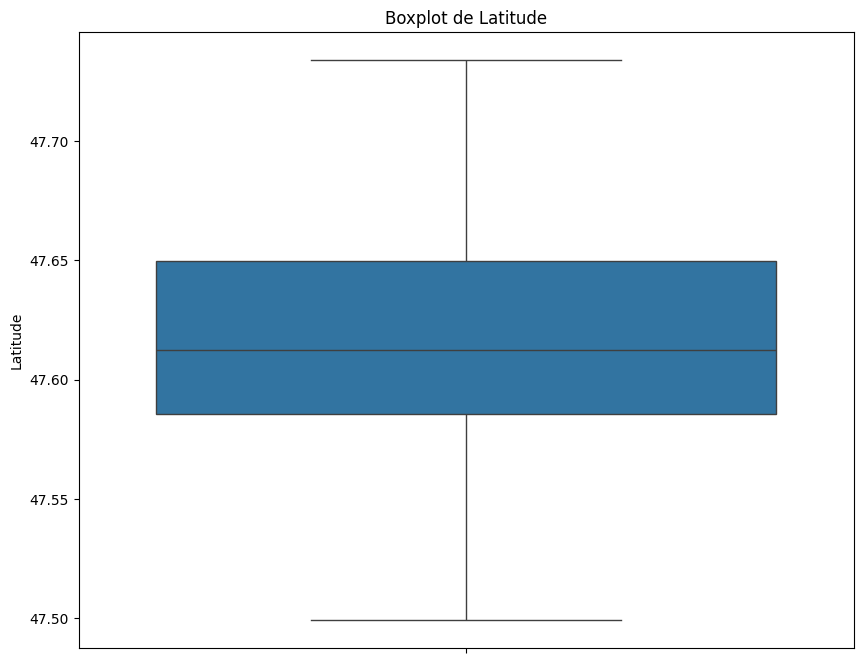

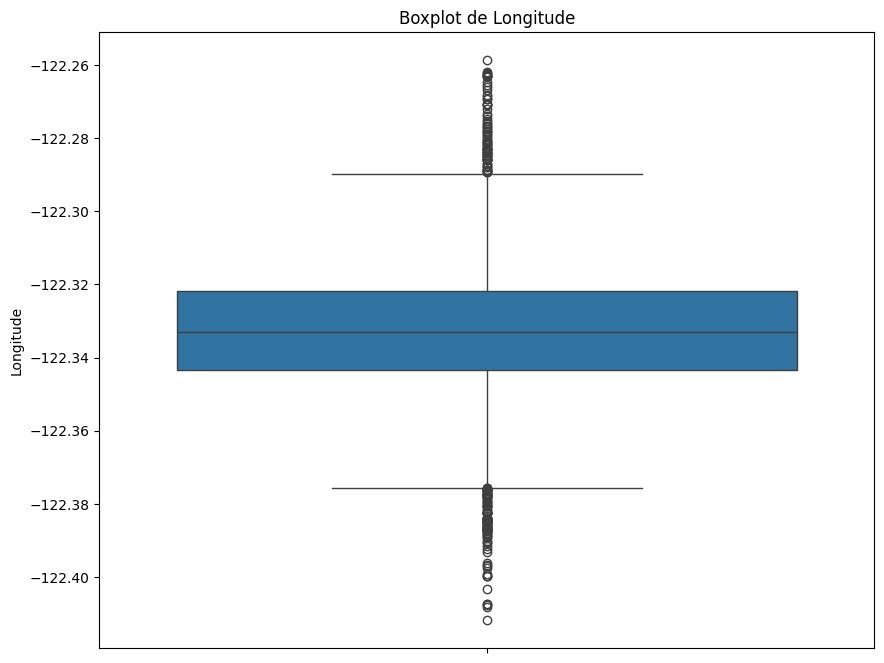

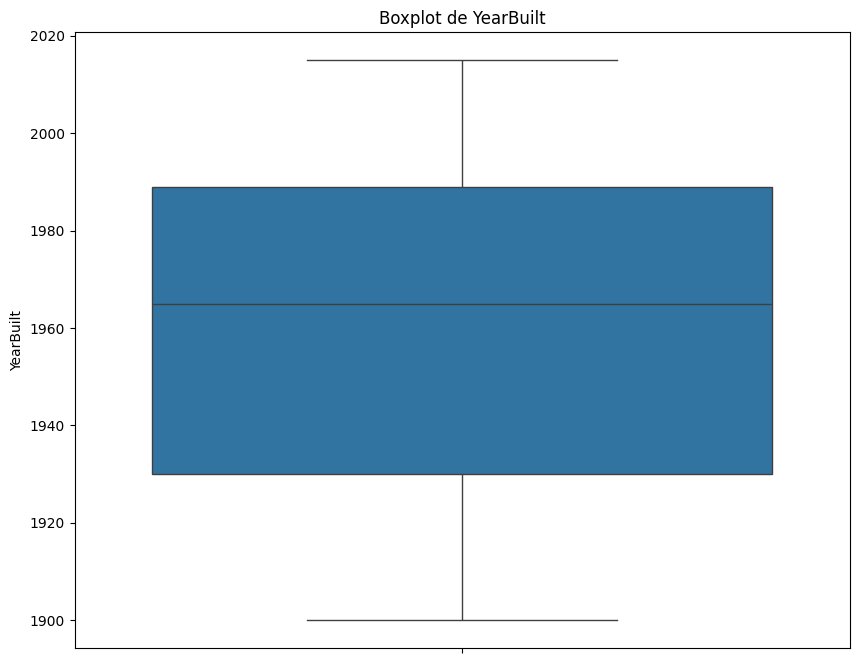

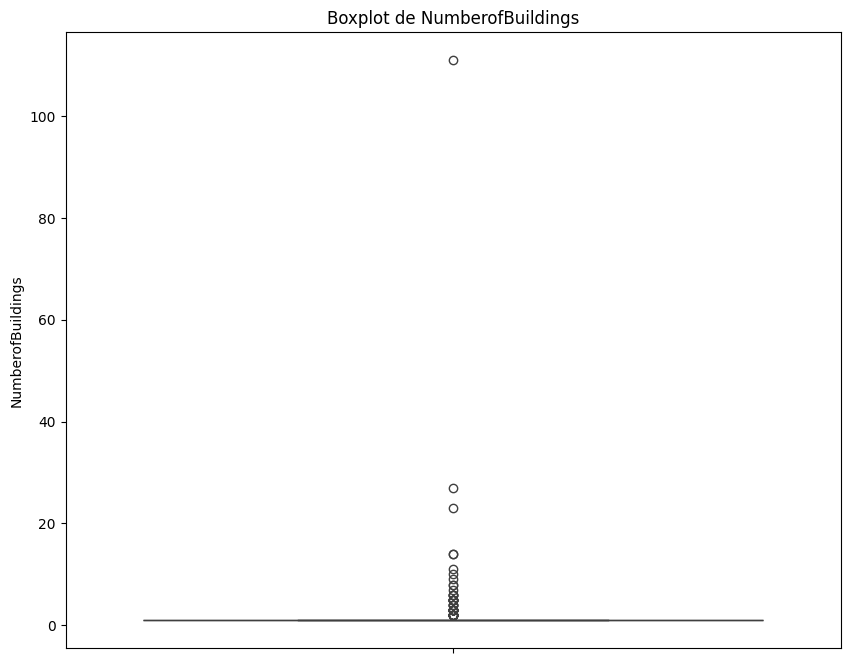

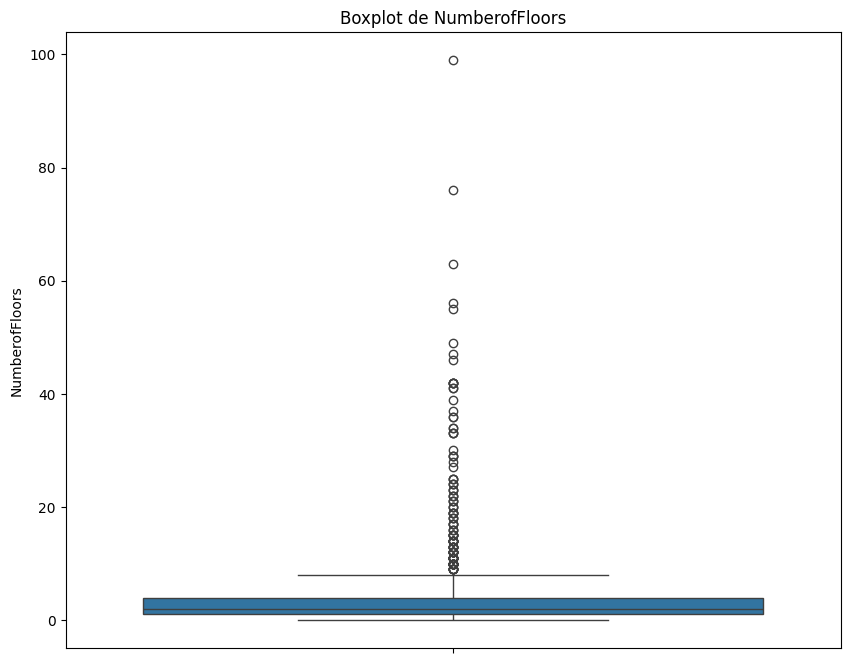

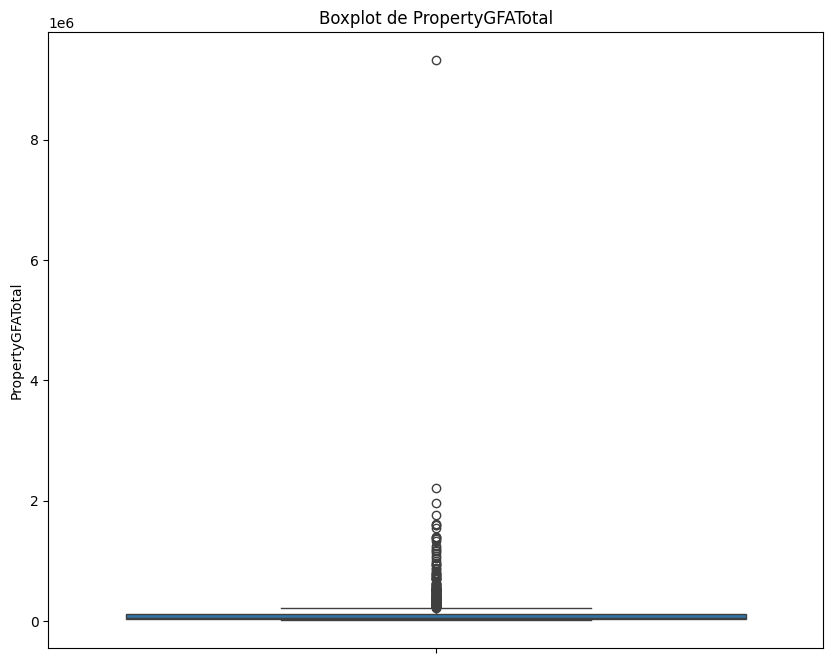

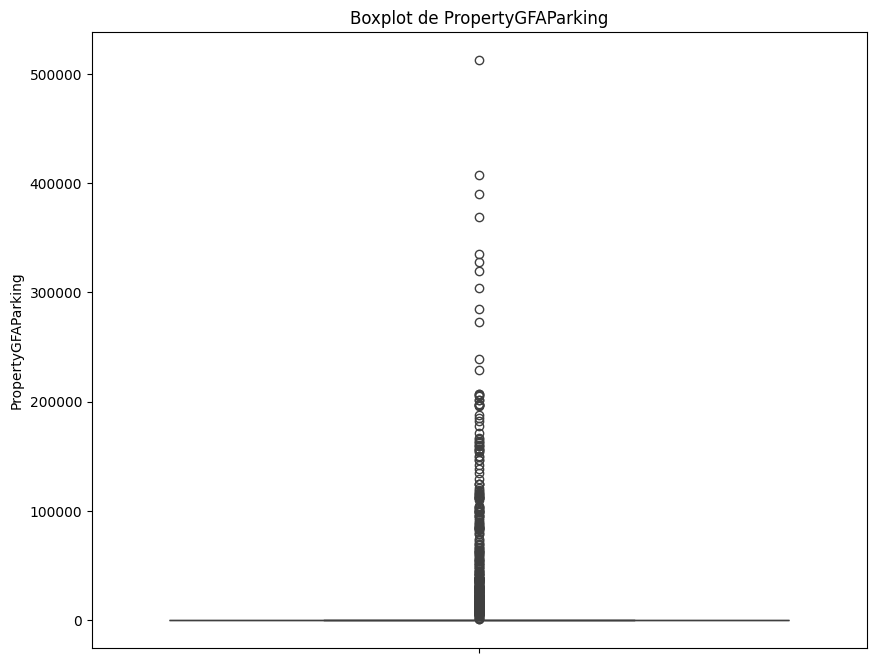

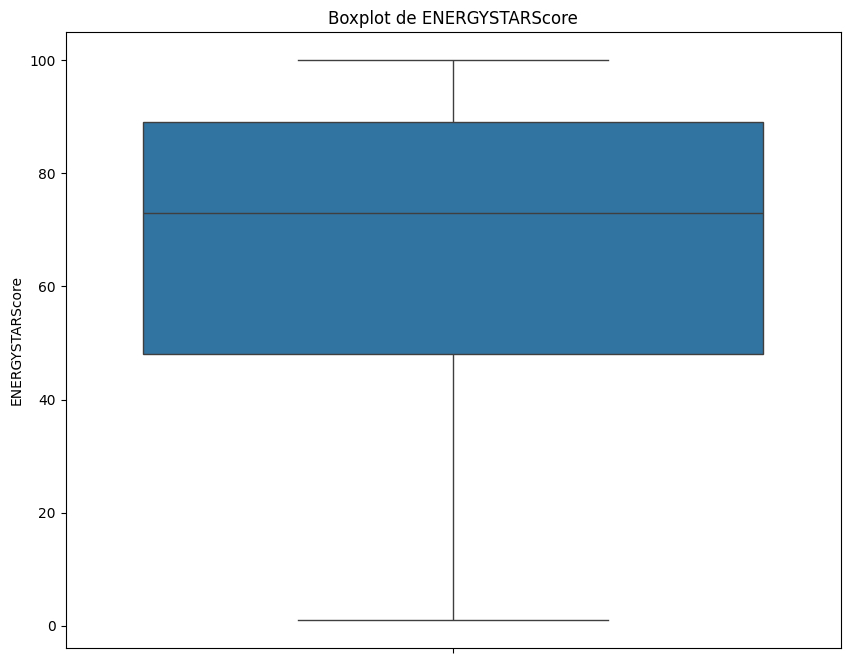

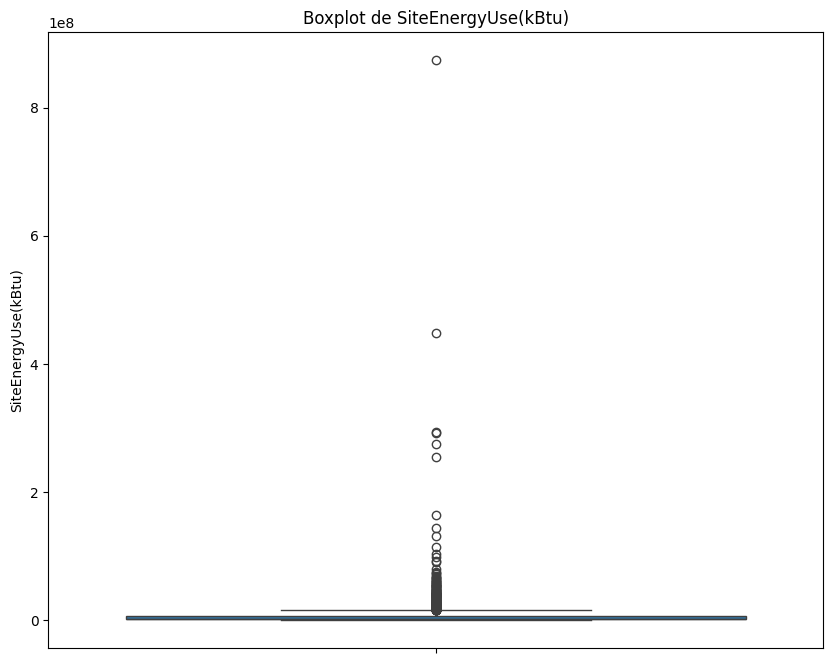

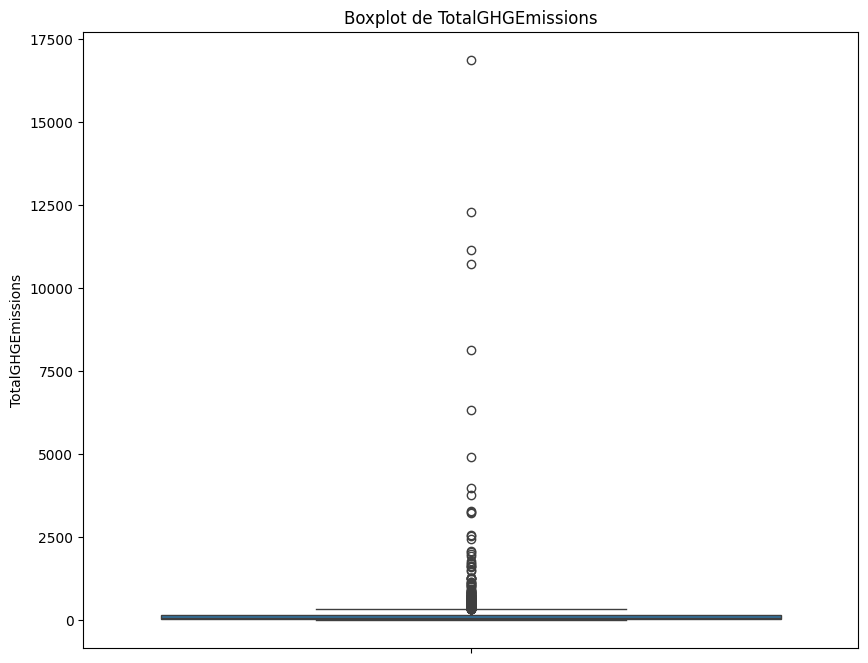

In [23]:
df.hist(bins=50, figsize=(20,15))
plt.show()

for col in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10,8))
    sns.boxplot(df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

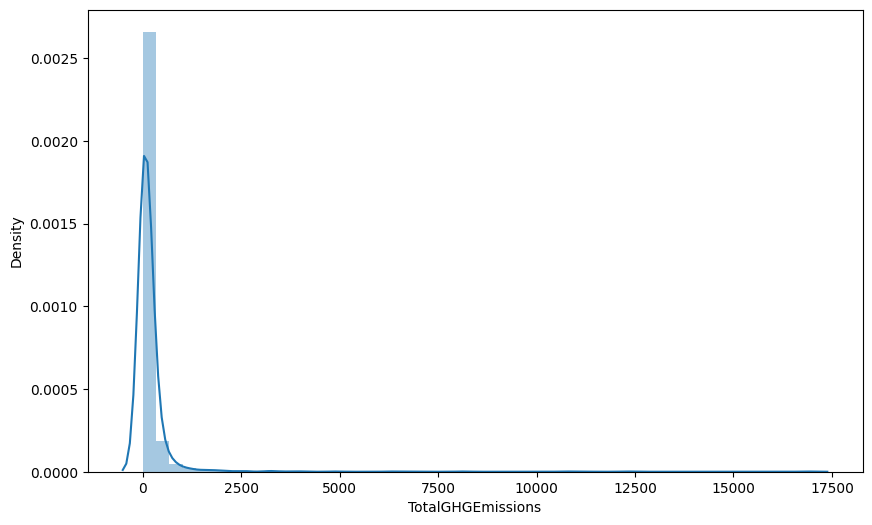

<Figure size 1000x600 with 0 Axes>

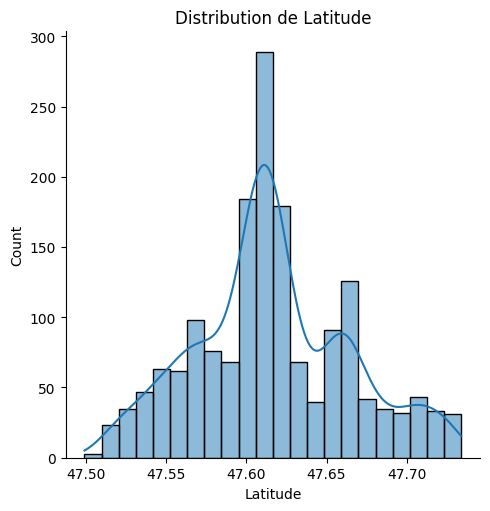

<Figure size 1000x600 with 0 Axes>

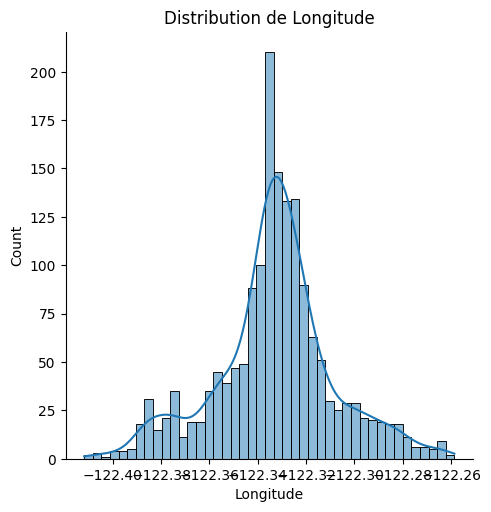

<Figure size 1000x600 with 0 Axes>

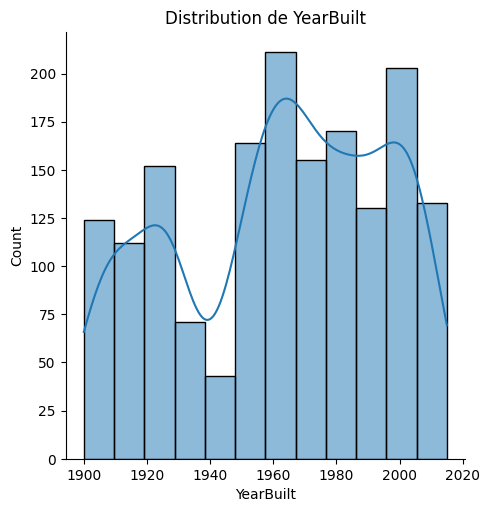

<Figure size 1000x600 with 0 Axes>

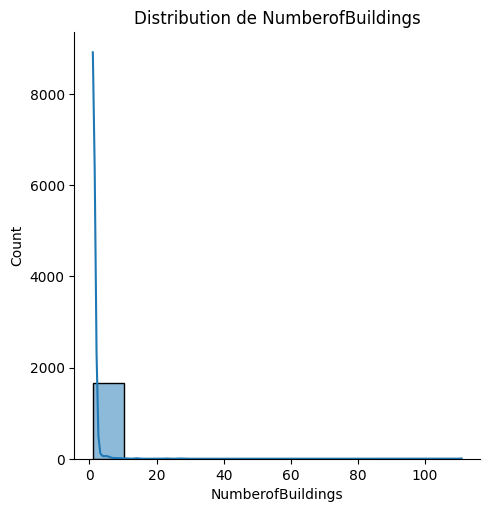

<Figure size 1000x600 with 0 Axes>

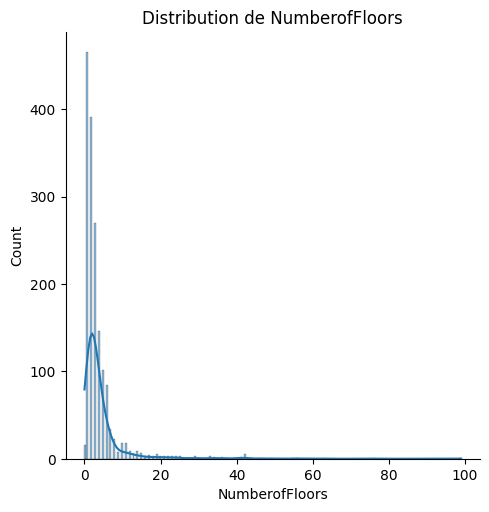

<Figure size 1000x600 with 0 Axes>

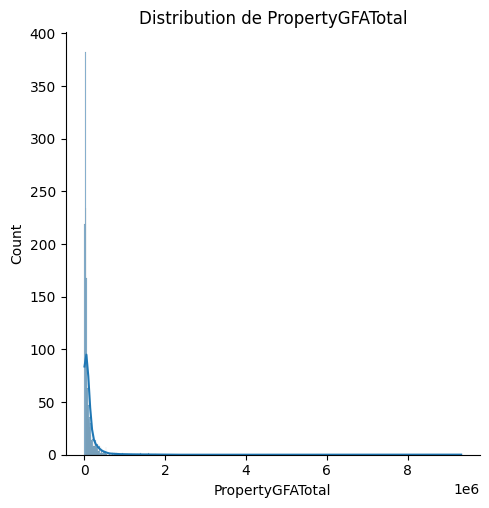

<Figure size 1000x600 with 0 Axes>

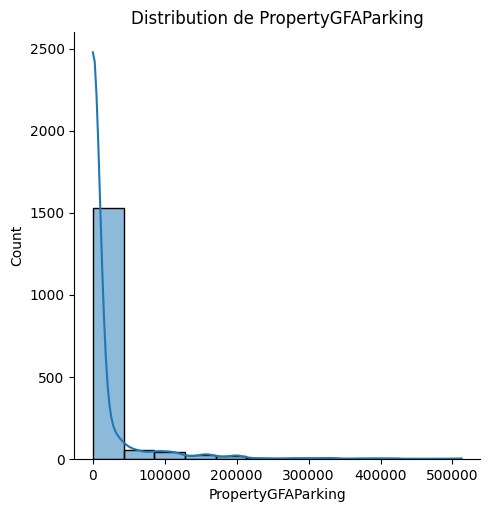

<Figure size 1000x600 with 0 Axes>

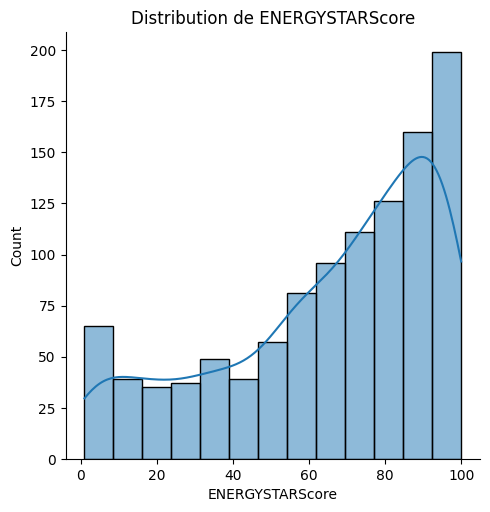

<Figure size 1000x600 with 0 Axes>

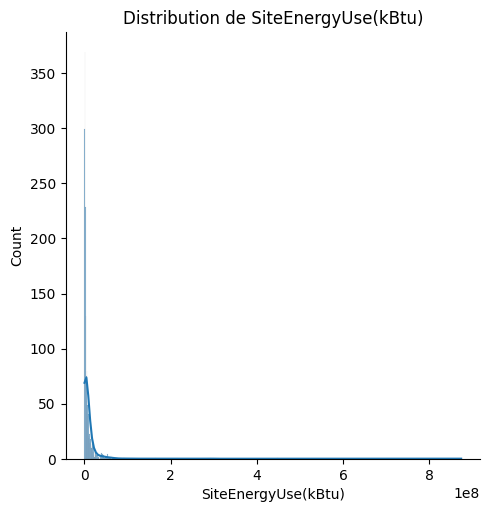

<Figure size 1000x600 with 0 Axes>

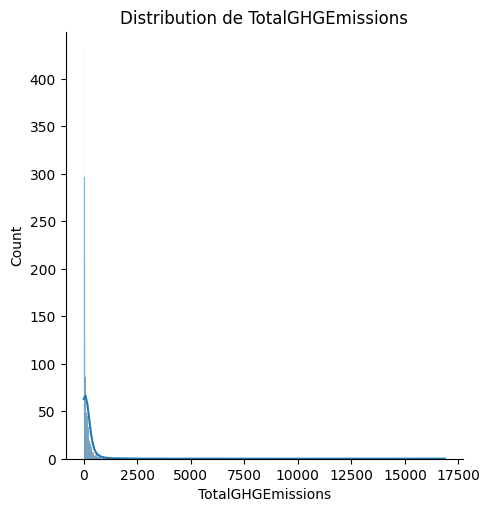

In [24]:
plt.figure(figsize=(10, 6))
sns.distplot(df['TotalGHGEmissions'], bins=50, kde=True)
plt.show()

for col in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.displot(df[col], kde=True)
    plt.title(f'Distribution de {col}')
    plt.show()

<Figure size 1000x800 with 0 Axes>

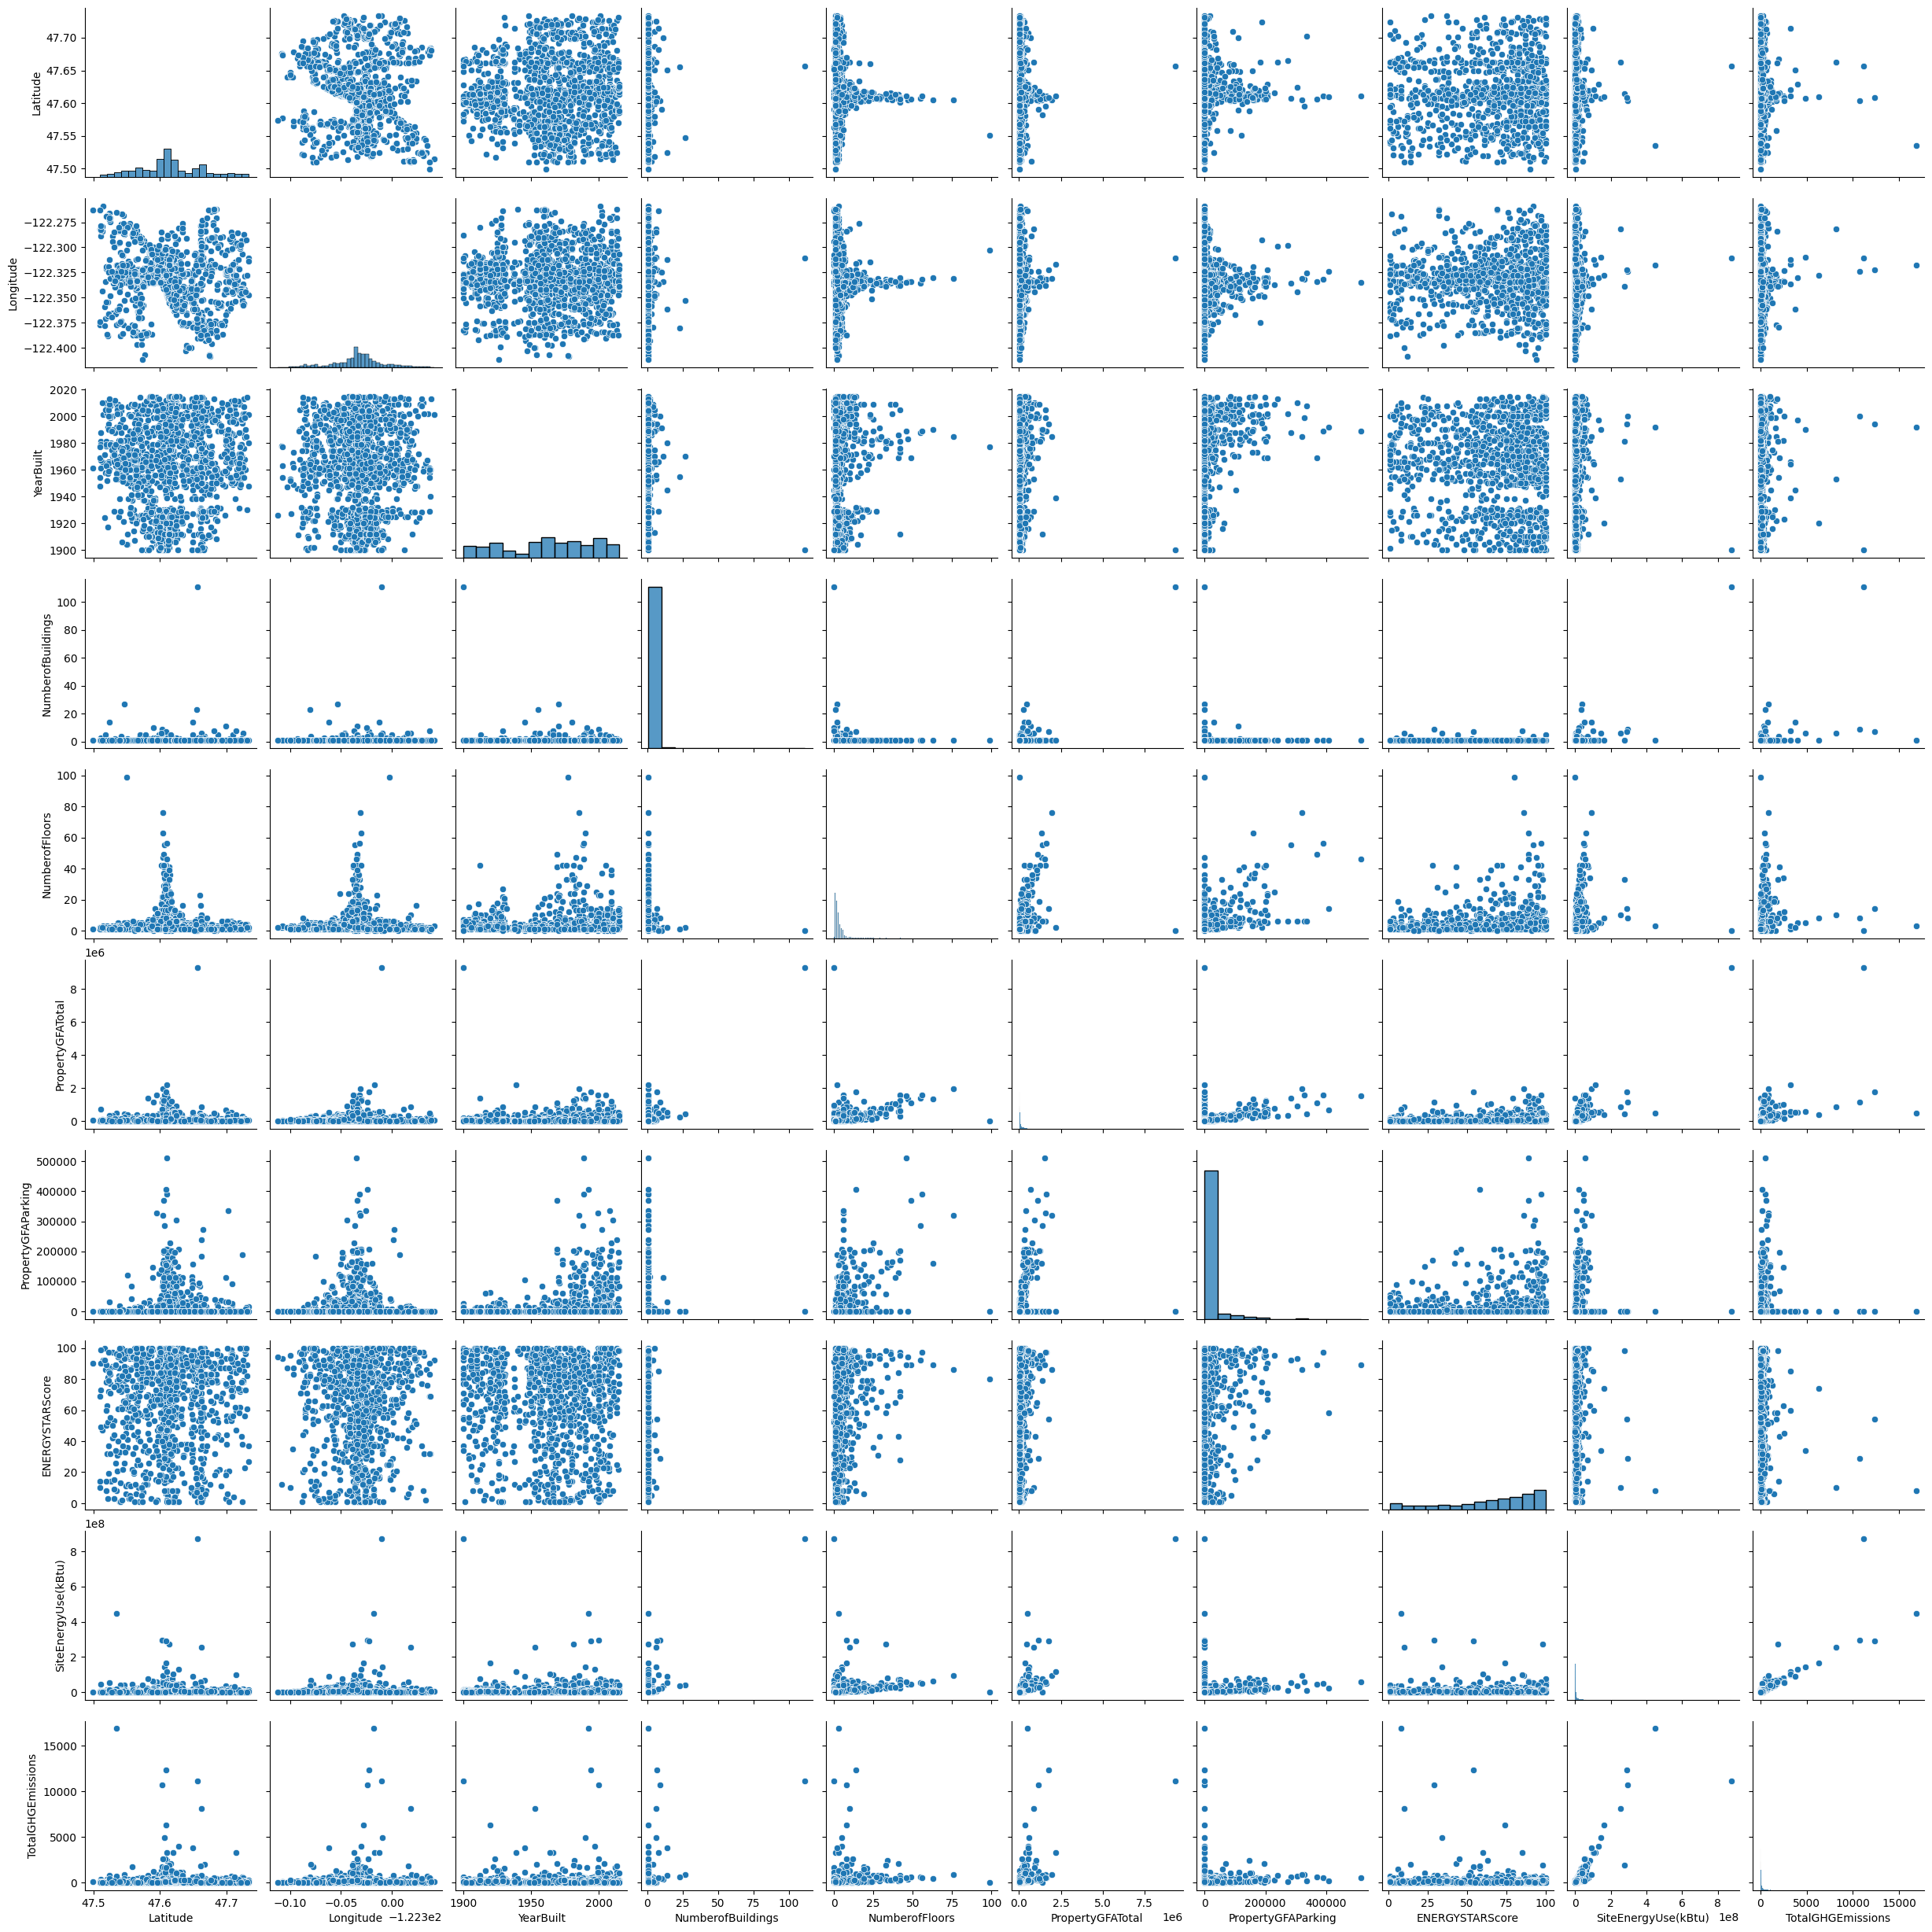

In [25]:
plt.figure(figsize=(10,8))
sns.pairplot(df)
plt.show()


In [26]:

import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",


    color="SiteEnergyUse(kBtu)",


    size="PropertyGFATotal",


    hover_data={
        "Neighborhood": True,
        "PrimaryPropertyType": True,
        "YearBuilt": True,
        "TotalGHGEmissions": ":.2f",
        "PropertyGFATotal": ":.0f",
        "Latitude": False,
        "Longitude": False
    },


    color_continuous_scale=px.colors.sequential.Reds,

    zoom=10,
    height=650
)

fig.update_layout(
    mapbox_style="carto-darkmatter",
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.show()

In [27]:

df_tree = df[
    (df["TotalGHGEmissions"] > 0) &
    df["Neighborhood"].notna() &
    df["PrimaryPropertyType"].notna()
]


fig = px.treemap(
    df_tree,
    path=["Neighborhood", "PrimaryPropertyType"],
    values="SiteEnergyUse(kBtu)",
    color="SiteEnergyUse(kBtu)",
    color_continuous_scale="Reds"
)

fig.update_layout(
    title="Répartition hiérarchique des émissions de CO₂ par quartier et type de bâtiment",
    height=650
)

fig.show()

In [28]:
num_col = df.select_dtypes(include='number').columns

corr = df[num_col].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto"
)

fig.update_layout(
    title="Matrice de corrélation – Analyse exploratoire",
    height=600
)

fig.show()

In [29]:
df['building_age']       = 2016 - df['YearBuilt']
df['ThermalCompactness'] = df['NumberofFloors'] / np.sqrt(df['PropertyGFATotal'])
df['FloorDensity']       = df['NumberofFloors'] / df['PropertyGFATotal'].replace(0, np.nan)
df['parking_ratio']      = df['PropertyGFAParking'] / df['PropertyGFATotal'].replace(0, np.nan)
df['surface_per_floor']  = df['PropertyGFATotal'] / df['NumberofFloors'].replace(0, np.nan)

In [30]:
lat_centre = df['Latitude'].mean()
lon_centre = df['Longitude'].mean()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df['distance_to_center_km'] = df.apply(
    lambda r: haversine(r['Latitude'], r['Longitude'], lat_centre, lon_centre),
    axis=1
)


In [31]:
df['has_energy_star'] = df['ENERGYSTARScore'].notna().astype(int)
df['ENERGYSTARScore_imputed'] = df.groupby(
    ['BuildingType', 'PrimaryPropertyType']
)['ENERGYSTARScore'].transform(lambda x: x.fillna(x.median()))
df['ENERGYSTARScore_imputed'] = df['ENERGYSTARScore_imputed'].fillna(
    df['ENERGYSTARScore'].median()
)

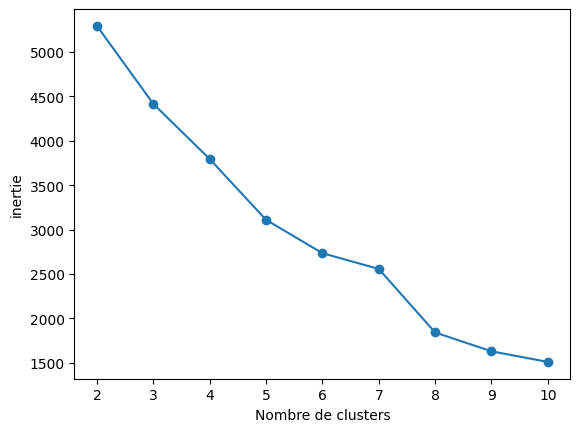

In [32]:
feautres_à_regrouper = ['Latitude','Longitude','YearBuilt','PropertyGFATotal']

scaler = StandardScaler()

features_scaled = scaler.fit_transform(df[feautres_à_regrouper])

inertia = []
k = range(2,11)

for a in k :
  kmeans = KMeans(n_clusters = a, random_state=42)
  kmeans.fit(features_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(k,inertia,marker="o")
plt.xlabel('Nombre de clusters')
plt.ylabel('inertie')
plt.show()

In [33]:

kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster_ID"] = kmeans.fit_predict(features_scaled)

import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Cluster_ID",
    zoom=10,
    height=600
)

fig.update_layout(mapbox_style="carto-darkmatter")
fig.show()


In [34]:
num_col = df.select_dtypes(include='number').columns

corr = df[num_col].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto"
)

fig.update_layout(
    title="Matrice de corrélation – Analyse exploratoire",
    height=600
)

fig.show()

In [35]:
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

    n_outliers = len(outliers)
    total = len(df)
    pourcentage = (n_outliers / total) * 100

    print(f"{col} : {n_outliers} valeurs aberrantes ({pourcentage:.2f}%)")

Latitude : 0 valeurs aberrantes (0.00%)
Longitude : 199 valeurs aberrantes (11.93%)
YearBuilt : 0 valeurs aberrantes (0.00%)
NumberofBuildings : 53 valeurs aberrantes (3.18%)
NumberofFloors : 138 valeurs aberrantes (8.27%)
PropertyGFATotal : 203 valeurs aberrantes (12.17%)
PropertyGFAParking : 333 valeurs aberrantes (19.96%)
ENERGYSTARScore : 0 valeurs aberrantes (0.00%)
SiteEnergyUse(kBtu) : 188 valeurs aberrantes (11.27%)
TotalGHGEmissions : 178 valeurs aberrantes (10.67%)
building_age : 0 valeurs aberrantes (0.00%)
ThermalCompactness : 77 valeurs aberrantes (4.62%)
FloorDensity : 33 valeurs aberrantes (1.98%)
parking_ratio : 333 valeurs aberrantes (19.96%)
surface_per_floor : 115 valeurs aberrantes (6.89%)
distance_to_center_km : 0 valeurs aberrantes (0.00%)
has_energy_star : 0 valeurs aberrantes (0.00%)
ENERGYSTARScore_imputed : 152 valeurs aberrantes (9.11%)
Cluster_ID : 0 valeurs aberrantes (0.00%)


<Figure size 1000x600 with 0 Axes>

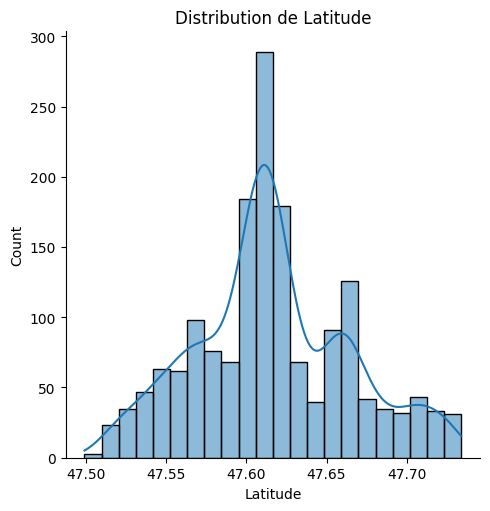

<Figure size 1000x600 with 0 Axes>

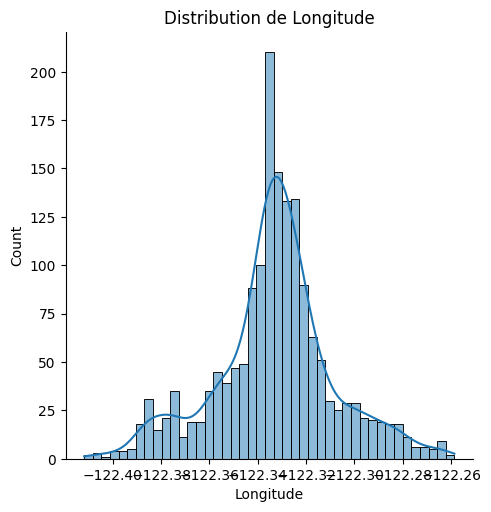

<Figure size 1000x600 with 0 Axes>

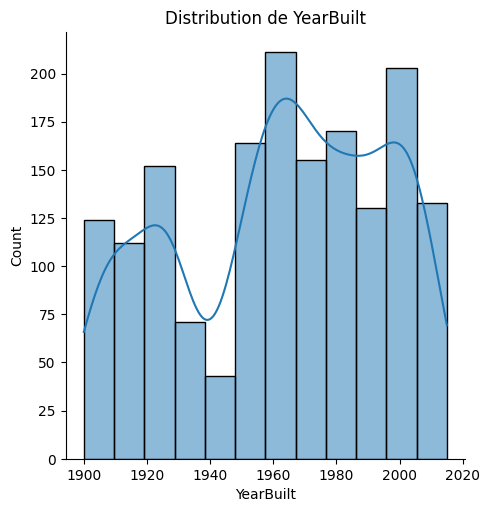

<Figure size 1000x600 with 0 Axes>

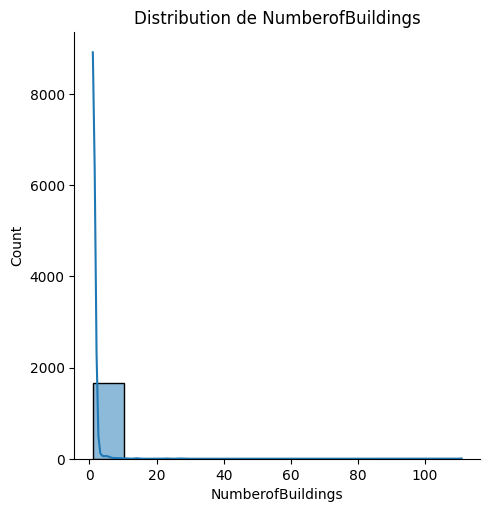

<Figure size 1000x600 with 0 Axes>

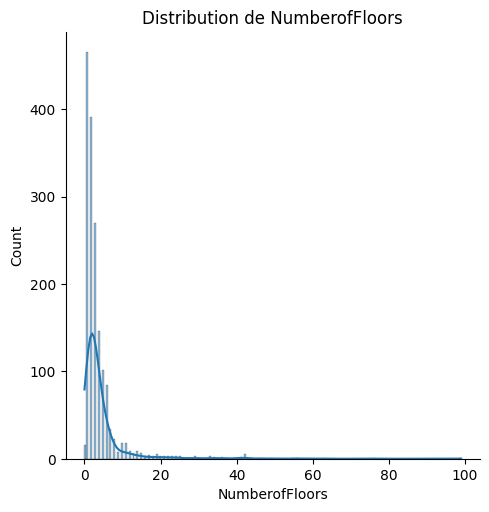

<Figure size 1000x600 with 0 Axes>

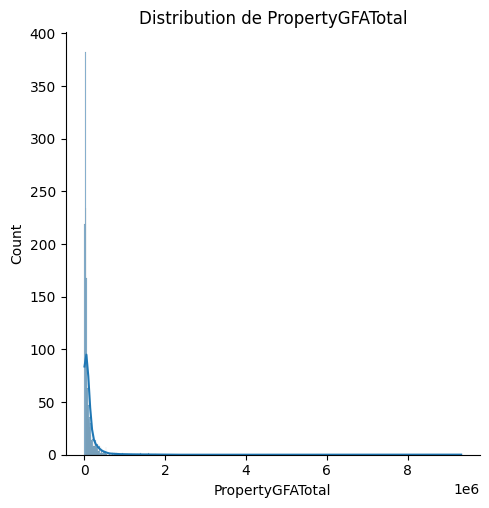

<Figure size 1000x600 with 0 Axes>

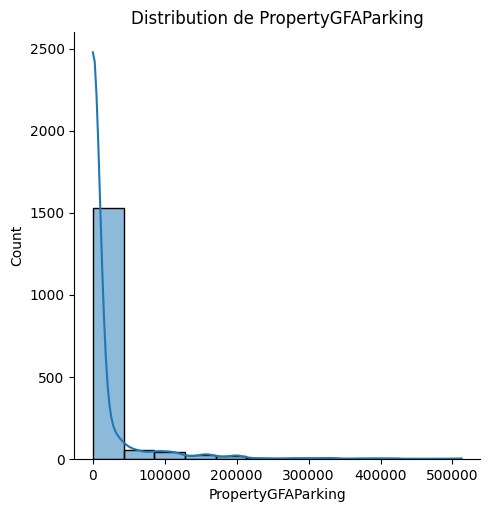

<Figure size 1000x600 with 0 Axes>

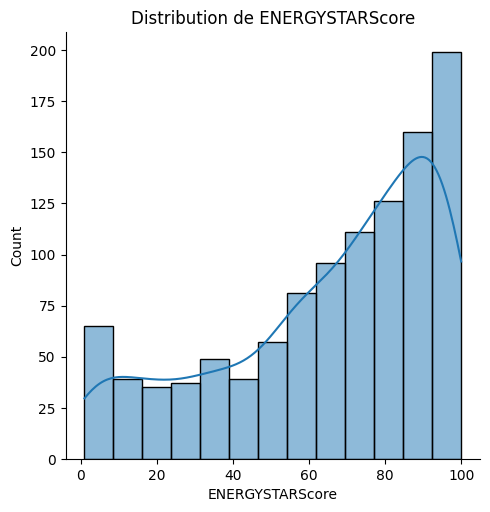

<Figure size 1000x600 with 0 Axes>

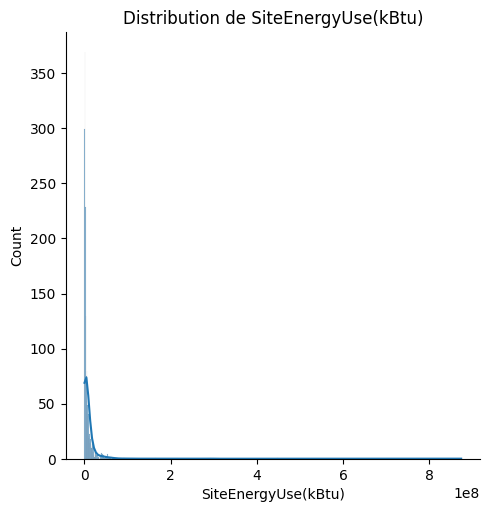

<Figure size 1000x600 with 0 Axes>

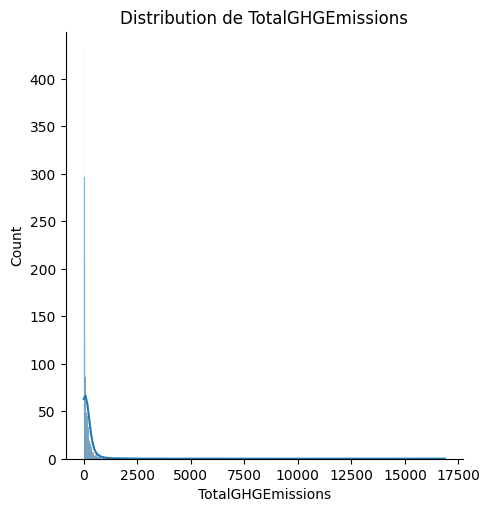

<Figure size 1000x600 with 0 Axes>

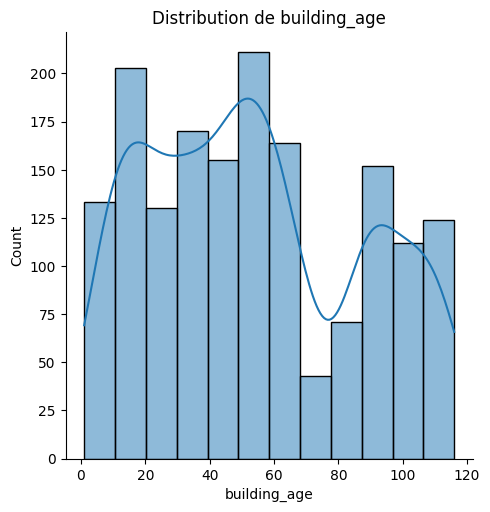

<Figure size 1000x600 with 0 Axes>

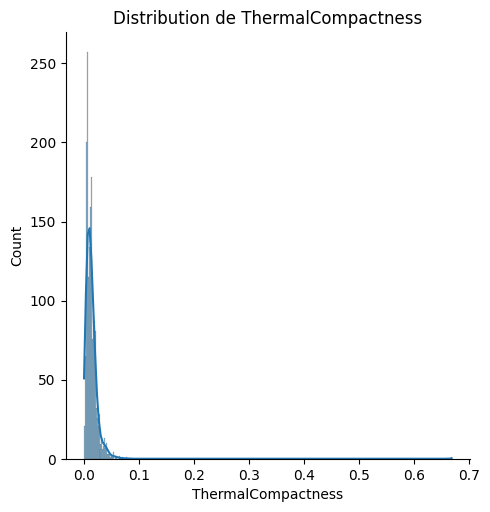

<Figure size 1000x600 with 0 Axes>

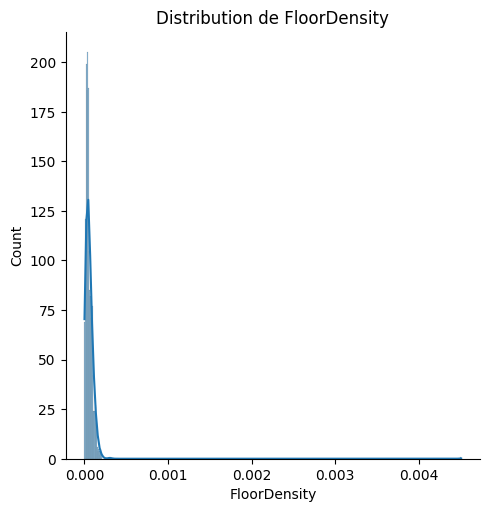

<Figure size 1000x600 with 0 Axes>

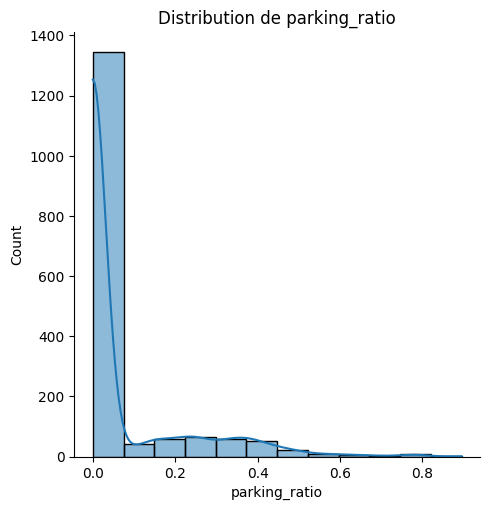

<Figure size 1000x600 with 0 Axes>

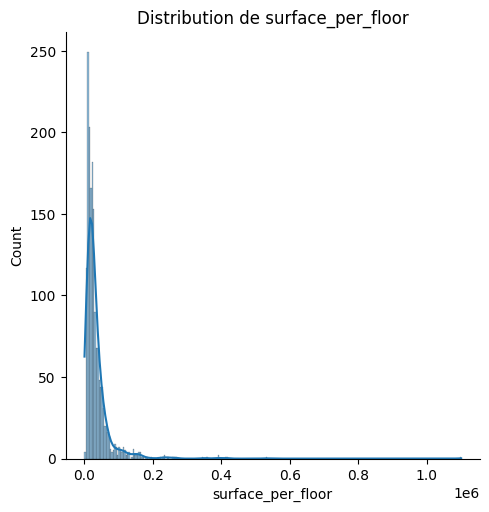

<Figure size 1000x600 with 0 Axes>

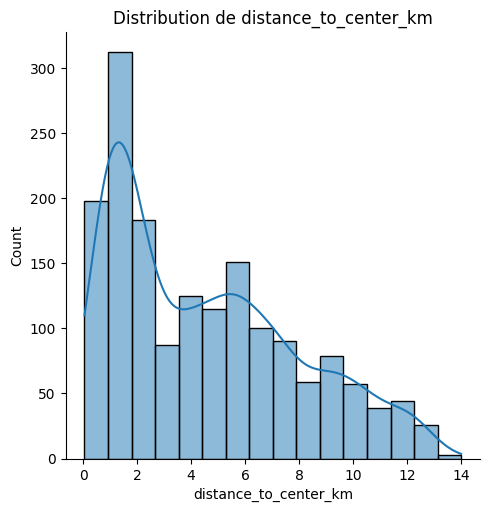

<Figure size 1000x600 with 0 Axes>

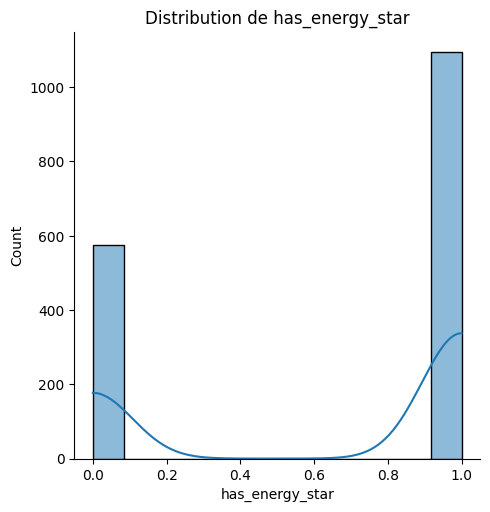

<Figure size 1000x600 with 0 Axes>

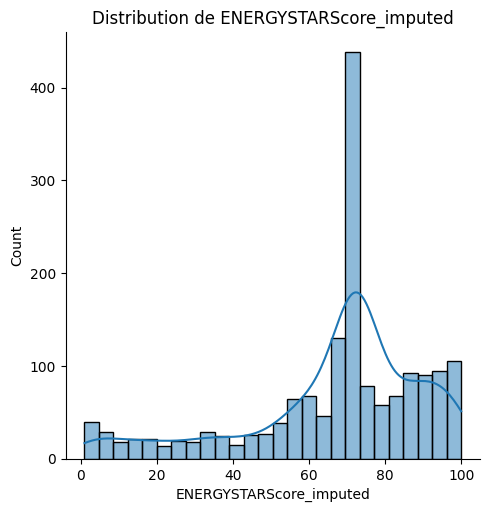

<Figure size 1000x600 with 0 Axes>

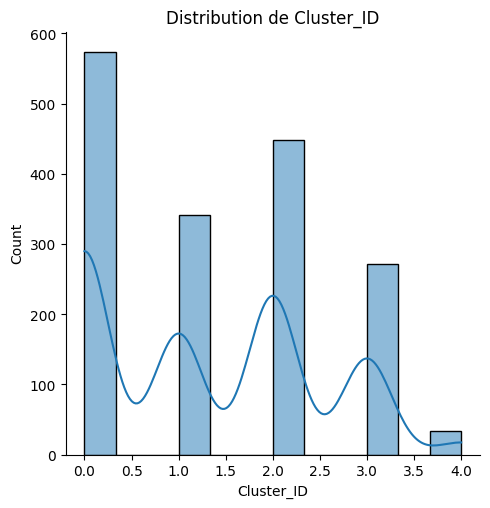

In [36]:
for col in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.displot(df[col], kde=True)
    plt.title(f'Distribution de {col}')
    plt.show()

In [37]:
cols_to_log = [
    'PropertyGFATotal', 'PropertyGFAParking', 'NumberofBuildings',
    'NumberofFloors', 'ThermalCompactness', 'FloorDensity',
    'parking_ratio', 'distance_to_center_km', 'surface_per_floor'
]
for col in cols_to_log:
    df[f'log_{col}'] = np.log1p(df[col].fillna(0))

print(f"Feature engineering terminé : {df.shape}")

Feature engineering terminé : (1668, 32)


In [38]:
num_features = [

    'log_PropertyGFATotal',
    'log_NumberofBuildings',
    'log_NumberofFloors',
    'log_PropertyGFAParking',
    'log_ThermalCompactness',
    'log_FloorDensity',
    'log_parking_ratio',
    'log_distance_to_center_km',
    'log_surface_per_floor',
    'YearBuilt',
    'building_age',
    'Latitude',
    'Longitude',
    'ENERGYSTARScore_imputed',
    'has_energy_star'
]

ohe_features = ['BuildingType', 'Cluster_ID']
te_features  = ['Neighborhood', 'PrimaryPropertyType']
all_features = num_features + ohe_features + te_features
target = 'TotalGHGEmissions'
print(f"target : {target}")


target : TotalGHGEmissions


In [39]:
df_model = df.dropna(subset=[target]).copy()
df_model = df_model[df_model[target] > 0].copy()

In [40]:
q99 = df_model[target].quantile(0.99)
df_model = df_model[df_model[target] <= q99].copy()


print(f"\n Dataset final : {df_model.shape}")



 Dataset final : (1642, 32)


In [41]:
y = np.log1p(df_model[target])
X = df_model[all_features].copy()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Train : {X_train.shape}")
print(f"✅ Test  : {X_test.shape}")

✅ Train : (1313, 19)
✅ Test  : (329, 19)


In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('ohe', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), ohe_features),
        ('te', ce.TargetEncoder(
            cols=te_features,
            smoothing=10
        ), te_features)
    ]
)

In [44]:

models = {
    'Ridge': Ridge(alpha=10.0),

    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=0.6,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=0.5,
        reg_alpha=0.3,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=20,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.3,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    ),
}

results = {}
pipelines = {}


print(f" Ccomparaison des modèles : {target}")


 Ccomparaison des modèles : TotalGHGEmissions


In [45]:
for name, regressor in models.items():

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', regressor)
    ])

    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test  = pipe.predict(X_test)

    # Métriques log space
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Métriques échelle originale
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_test)
    r2_orig     = r2_score(y_test_orig, y_pred_orig)
    mask        = y_test_orig > 0
    mape        = mean_absolute_percentage_error(y_test_orig[mask], y_pred_orig[mask])

    # Cross-validation
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)


    print(f" {name}")
    print(f"  R2 train      : {r2_train:.3f}")
    print(f"  R2 test (log) : {r2_test:.3f}")
    print(f"  R2 test (orig): {r2_orig:.3f}")
    print(f"  MAPE          : {mape:.1%}")
    print(f"  RMSE (log)    : {rmse:.3f}")
    print(f"  CV R2         : {cv.mean():.3f} ± {cv.std():.3f}")
    print(f"  Overfit       : {r2_train - r2_test:.3f}")

    results[name]  = {
        'R2_train': r2_train, 'R2_test_log': r2_test,
        'R2_test_orig': r2_orig, 'MAPE': mape,
        'RMSE': rmse, 'CV_mean': cv.mean(),
        'CV_std': cv.std(), 'Overfit': r2_train - r2_test
    }
    pipelines[name] = pipe


 Ridge
  R2 train      : 0.506
  R2 test (log) : 0.427
  R2 test (orig): 0.278
  MAPE          : 209.9%
  RMSE (log)    : 1.018
  CV R2         : 0.475 ± 0.026
  Overfit       : 0.079
 RandomForest
  R2 train      : 0.658
  R2 test (log) : 0.464
  R2 test (orig): 0.357
  MAPE          : 198.4%
  RMSE (log)    : 0.984
  CV R2         : 0.495 ± 0.021
  Overfit       : 0.193
 XGBoost
  R2 train      : 0.811
  R2 test (log) : 0.497
  R2 test (orig): 0.458
  MAPE          : 173.3%
  RMSE (log)    : 0.953
  CV R2         : 0.517 ± 0.025
  Overfit       : 0.314
 LightGBM
  R2 train      : 0.791
  R2 test (log) : 0.498
  R2 test (orig): 0.431
  MAPE          : 163.3%
  RMSE (log)    : 0.953
  CV R2         : 0.507 ± 0.024
  Overfit       : 0.294


In [46]:
results_df = pd.DataFrame(results).T.sort_values('CV_mean', ascending=False)

print(" Classement finalL")

print(results_df.round(3).to_string())


best_name = results_df.index[0]
best_pipe = pipelines[best_name]

print(f"\n Meilleur modèle : {best_name}")
print(f" CV R2    : {results_df.loc[best_name,'CV_mean']:.3f}")
print(f" Test R2  : {results_df.loc[best_name,'R2_test_log']:.3f}")
print(f" Overfit  : {results_df.loc[best_name,'Overfit']:.3f}")


 Classement finalL
              R2_train  R2_test_log  R2_test_orig   MAPE   RMSE  CV_mean  CV_std  Overfit
XGBoost          0.811        0.497         0.458  1.733  0.953    0.517   0.025    0.314
LightGBM         0.791        0.498         0.431  1.633  0.953    0.507   0.024    0.294
RandomForest     0.658        0.464         0.357  1.984  0.984    0.495   0.021    0.193
Ridge            0.506        0.427         0.278  2.099  1.018    0.475   0.026    0.079

 Meilleur modèle : XGBoost
 CV R2    : 0.517
 Test R2  : 0.497
 Overfit  : 0.314


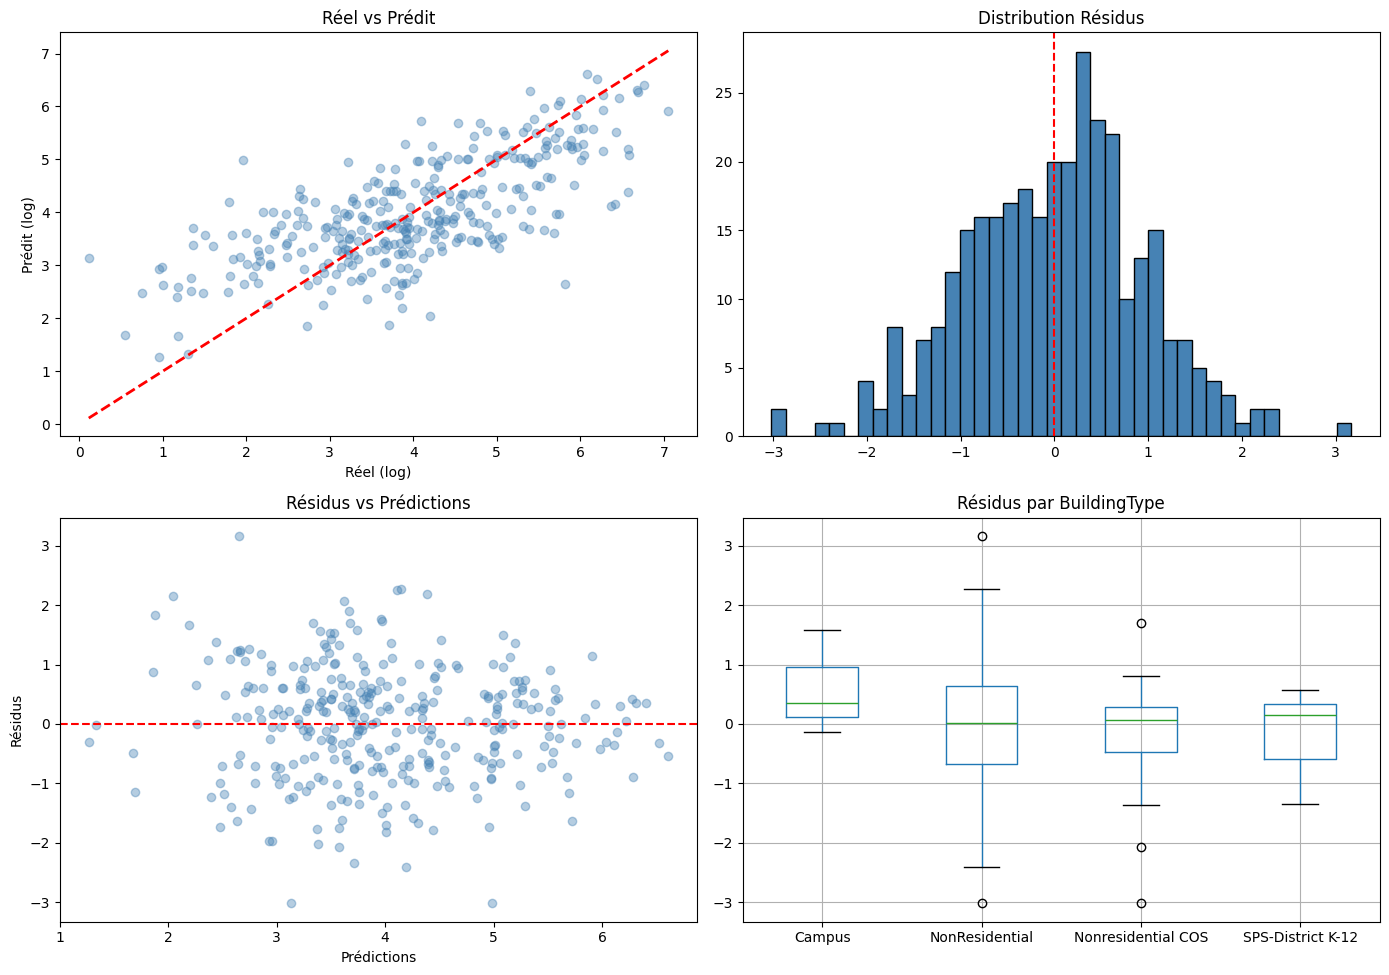

In [47]:
y_pred_best = best_pipe.predict(X_test)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Analyse Résidus — {best_name} — Consommation', fontsize=14)

# Réel vs Prédit
axes[0,0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue')
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Réel (log)')
axes[0,0].set_ylabel('Prédit (log)')
axes[0,0].set_title('Réel vs Prédit')

# Distribution résidus
axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='black')
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title('Distribution Résidus')

# Résidus vs Prédictions (hétéroscédasticité ?)
axes[1,0].scatter(y_pred_best, residuals, alpha=0.4, color='steelblue')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel('Prédictions')
axes[1,0].set_ylabel('Résidus')
axes[1,0].set_title('Résidus vs Prédictions')

pd.DataFrame({
    'residuals': residuals.values,
    'BuildingType': X_test['BuildingType'].values
}).boxplot(column='residuals', by='BuildingType', ax=axes[1,1])
axes[1,1].set_title('Résidus par BuildingType')
axes[1,1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()


🔝 TOP 15 FEATURES :
                       feature  importance
          log_PropertyGFATotal    0.187039
           PrimaryPropertyType    0.126238
            log_NumberofFloors    0.080571
       ENERGYSTARScore_imputed    0.056655
             log_parking_ratio    0.041989
              log_FloorDensity    0.041707
   BuildingType_NonResidential    0.039375
        log_PropertyGFAParking    0.035440
BuildingType_SPS-District K-12    0.031529
                  Neighborhood    0.030584
     log_distance_to_center_km    0.030022
                  building_age    0.029030
                     YearBuilt    0.028365
               has_energy_star    0.027055
                  Cluster_ID_2    0.026273


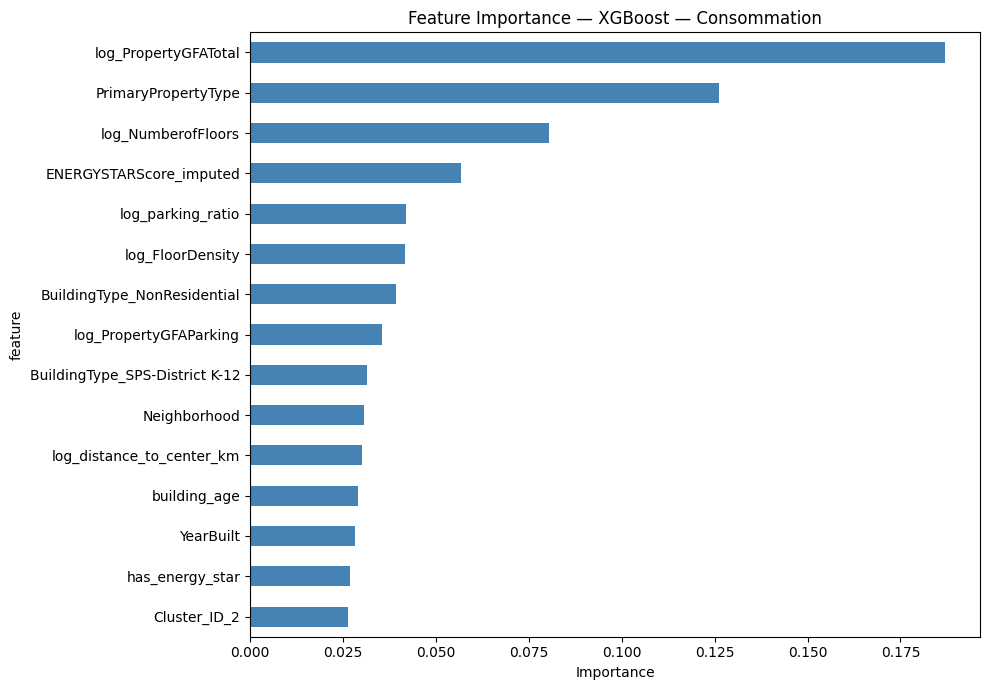

In [48]:
if best_name in ['XGBoost', 'LightGBM', 'RandomForest']:

    reg = best_pipe.named_steps['regressor']
    pre = best_pipe.named_steps['preprocess']

    try:
        ohe_names = list(pre.named_transformers_['ohe']
                         .get_feature_names_out(ohe_features))
    except:
        ohe_names = ohe_features

    feature_names = num_features + ohe_names + te_features
    importances   = reg.feature_importances_
    n             = min(len(importances), len(feature_names))

    fi_df = pd.DataFrame({
        'feature': feature_names[:n],
        'importance': importances[:n]
    }).sort_values('importance', ascending=False)

    print("\n🔝 TOP 15 FEATURES :")
    print(fi_df.head(15).to_string(index=False))

    fi_df.head(15).sort_values('importance').plot(
        x='feature', y='importance', kind='barh',
        figsize=(10, 7), color='steelblue', legend=False,
        title=f'Feature Importance — {best_name} — Consommation'
    )
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

In [49]:

joblib.dump(best_pipe, 'model_consumption.pkl')
print(f"\n Modèle sauvegardé : model_consumption.pkl")
print(f" Modèle : {best_name}")
print(f" R2 CV  : {results_df.loc[best_name,'CV_mean']:.3f}")
print(f" MAPE   : {results_df.loc[best_name,'MAPE']:.1%}")


 Modèle sauvegardé : model_consumption.pkl
 Modèle : XGBoost
 R2 CV  : 0.517
 MAPE   : 173.3%


### Prediction sans Energy_star


In [50]:
num_features_no_energy = [
    'log_PropertyGFATotal',
    'log_NumberofBuildings',
    'log_NumberofFloors',
    'log_PropertyGFAParking',
    'log_ThermalCompactness',
    'log_FloorDensity',
    'log_parking_ratio',
    'log_distance_to_center_km',
    'log_surface_per_floor',
    'YearBuilt',
    'building_age',
    'Latitude',
    'Longitude',
]

ohe_features = ['BuildingType', 'Cluster_ID']
te_features  = ['Neighborhood', 'PrimaryPropertyType']

all_features_no_energy = (
    num_features_no_energy +
    ohe_features +
    te_features
)



df_model_no_energy = df.dropna(subset=[target]).copy()
df_model_no_energy = df_model_no_energy[df_model_no_energy[target] > 0].copy()

q99 = df_model_no_energy[target].quantile(0.99)
df_model_no_energy = df_model_no_energy[df_model_no_energy[target] <= q99].copy()

y_no_energy = np.log1p(df_model_no_energy[target])
X_no_energy = df_model_no_energy[all_features_no_energy].copy()



X_train_ne, X_test_ne, y_train_ne, y_test_ne = train_test_split(
    X_no_energy,
    y_no_energy,
    test_size=0.2,
    random_state=42
)



preprocessor_no_energy = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features_no_energy),
        ('ohe', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), ohe_features),
        ('te', ce.TargetEncoder(
            cols=te_features,
            smoothing=10
        ), te_features)
    ]
)



results_no_energy = {}
pipelines_no_energy = {}

for name, regressor in models.items():

    pipe_no_energy = Pipeline([
        ('preprocess', preprocessor_no_energy),
        ('regressor', regressor)
    ])

    pipe_no_energy.fit(X_train_ne, y_train_ne)

    y_pred_train = pipe_no_energy.predict(X_train_ne)
    y_pred_test  = pipe_no_energy.predict(X_test_ne)

    r2_train = r2_score(y_train_ne, y_pred_train)
    r2_test  = r2_score(y_test_ne,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test_ne, y_pred_test))

    y_test_orig = np.expm1(y_test_ne)
    y_pred_orig = np.expm1(y_pred_test)
    r2_orig     = r2_score(y_test_orig, y_pred_orig)

    mask = y_test_orig > 0
    mape = mean_absolute_percentage_error(
        y_test_orig[mask],
        y_pred_orig[mask]
    )

    cv = cross_val_score(
        pipe_no_energy,
        X_train_ne,
        y_train_ne,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    results_no_energy[name] = {
        'R2_train': r2_train,
        'R2_test_log': r2_test,
        'R2_test_orig': r2_orig,
        'MAPE': mape,
        'RMSE': rmse,
        'CV_mean': cv.mean(),
        'CV_std': cv.std(),
        'Overfit': r2_train - r2_test
    }

    pipelines_no_energy[name] = pipe_no_energy

In [51]:
pd.DataFrame(results_no_energy).T.sort_values("R2_test_log", ascending=False)

,R2_train,R2_test_log,R2_test_orig,MAPE,RMSE,CV_mean,CV_std,Overfit
XGBoost,0.778994,0.444599,0.386543,2.005478,1.001846,0.469230,0.034330,0.334396
LightGBM,0.764332,0.436743,0.368203,1.975929,1.008907,0.467241,0.033606,0.327589
RandomForest,0.630179,0.427898,0.311823,2.148164,1.016798,0.466083,0.023932,0.202281
Ridge,0.462934,0.378570,0.175994,2.268098,1.059727,0.429510,0.023435,0.084364
